### Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    auc
)


from ucimlrepo import fetch_ucirepo

# Carregar dataset
dataset = fetch_ucirepo(id=350)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

### remoçao dados duplicados 

In [3]:
dados = X.copy()
dados["Y"] = y.iloc[:, 0]
dados = dados.drop_duplicates()

dados_depois = len(dados)

print("Registros depois:", dados_depois)

X = dados.drop(columns=["Y"])
y = dados["Y"]

Registros depois: 29965


### tratando de X3 (nivel de educaçao)

In [4]:
X["X3"] = X["X3"].replace({
    0: 4,
    5: 4,
    6: 4
})
print(X["X3"].value_counts().sort_index())

X3
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64


### tratando dados de X4 (estado civil)

In [5]:
X["X4"] = X["X4"].replace({
    0: 3,
})

print(X["X4"].value_counts().sort_index())

X4
1    13643
2    15945
3      377
Name: count, dtype: int64


### preprocessar colunas

* X1 numerica continua - scaling
* X2-categorica nominal -one hot encoding
* X3-categorica ordinal - Ordinal Encoding
* X4-categorica nominal -one hot encoding
* X5-numericas discreta  - Scaling
* X6 - X11 categorica ordinal - Ordinal Encoding
* X12 - X17 numerica continua -scaling
* X18 - X23 numerica continua -scaling

In [6]:
# Variáveis numéricas
features_numericas = [
    "X1",
    "X5",
    "X6", "X7", "X8", "X9", "X10", "X11",
    "X12", "X13", "X14", "X15", "X16", "X17",
    "X18", "X19", "X20", "X21", "X22", "X23"
]

# Categóricas nominais
features_nominais = [
    "X2",
    "X4"
]

# Categórica ordinal
features_ordinais = [
    "X3"
]

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            features_numericas
        ),
        (
            "nominais",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_nominais
        ),
        (
            "ordinais",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            features_ordinais
        )
    ]
)

### Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Teste:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64


### Pipeline


In [8]:
modelo_logistico = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

### treino e previsões

In [9]:
modelo_logistico.fit(
    X_train,
    y_train
)

y_pred = modelo_logistico.predict(X_test)
y_prob = modelo_logistico.predict_proba(X_test)[:, 1]
modelo_logistico.score(X_test, y_test)

print("Previsões:")
print(pd.Series(y_pred).value_counts())

print("\nValores reais:")
print(y_test.value_counts())

cm = confusion_matrix(y_test, y_pred)

print(cm)


Previsões:
0    5538
1     455
Name: count, dtype: int64

Valores reais:
Y
0    4667
1    1326
Name: count, dtype: int64
[[4542  125]
 [ 996  330]]


In [10]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993

ROC-AUC: 0.7160981713975828


A regressão logística apresentou ROC-AUC de aproximadamente 0,716, indicando capacidade discriminativa superior ao acaso. Entretanto, o baixo recall da classe inadimplente demonstra que o modelo apresenta dificuldade em identificar uma parcela significativa dos casos positivos.

### thresholds

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.50 | Precision: 0.725 | Recall: 0.249 | F1: 0.371
Threshold: 0.45 | Precision: 0.683 | Recall: 0.318 | F1: 0.434
Threshold: 0.40 | Precision: 0.630 | Recall: 0.367 | F1: 0.463
Threshold: 0.35 | Precision: 0.598 | Recall: 0.411 | F1: 0.487
Threshold: 0.30 | Precision: 0.554 | Recall: 0.449 | F1: 0.496
Threshold: 0.25 | Precision: 0.453 | Recall: 0.553 | F1: 0.498
Threshold: 0.20 | Precision: 0.331 | Recall: 0.689 | F1: 0.447


Entre os thresholds avaliados, o valor de 0,25 apresentou o maior F1-score (0,498), aumentando substancialmente o recall da classe de inadimplência em relação ao threshold padrão de 0,50. Dessa forma, esse threshold será utilizado inicialmente nas análises subsequentes, sem considerá-lo como um valor definitivo

In [12]:


threshold = 0.25

y_pred_025 = (y_prob >= threshold).astype(int)

cm_025 = confusion_matrix(y_test, y_pred_025)

print(cm_025)

print(
    classification_report(
        y_test,
        y_pred_025
    )
)

[[3781  886]
 [ 593  733]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      4667
           1       0.45      0.55      0.50      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.68      0.67      5993
weighted avg       0.77      0.75      0.76      5993



A utilização do threshold padrão de 0,50 apresentou recall de 0,249 para a classe de inadimplência, identificando aproximadamente 25% dos clientes que efetivamente apresentaram inadimplência. Ao reduzir o threshold para 0,25, o recall aumentou para 0,553, permitindo identificar aproximadamente 55% dos casos positivos.
Essa melhora ocorreu às custas do aumento de falsos positivos, que passaram de 125 para 886. Consequentemente, a precision da classe positiva caiu de 0,725 para 0,453.
Entre os thresholds avaliados, 0,25 apresentou o maior F1-score (0,498), representando um equilíbrio mais favorável entre precision e recall. Portanto, esse valor será considerado como uma alternativa ao threshold padrão nas análises posteriores.

### precision reacal curve e curva roc

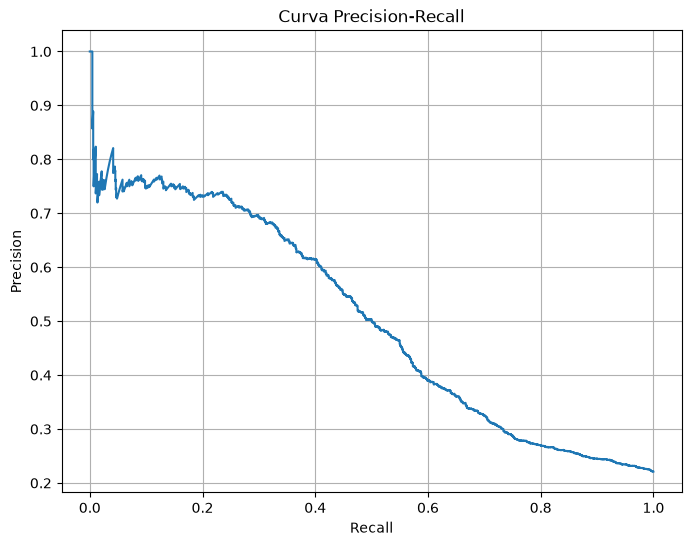

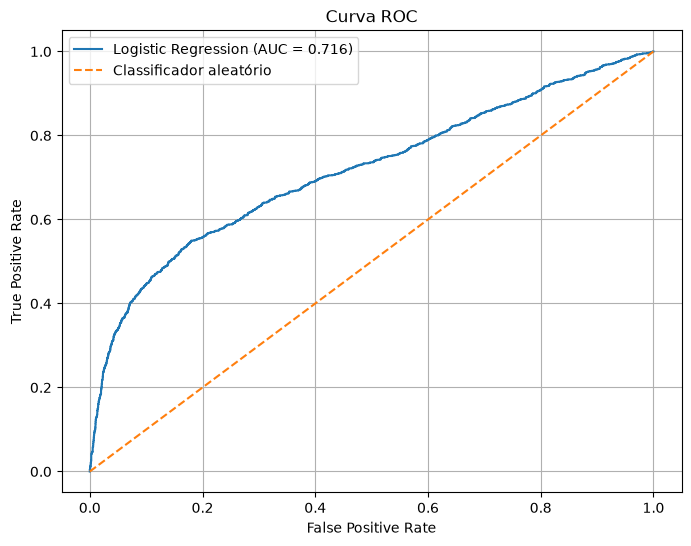

In [13]:

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.grid()
plt.show()


fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.legend()
plt.grid()

plt.show()

### Conclusão do Baseline — Regressão Logística

A regressão logística apresentou ROC-AUC de aproximadamente 0,716,
demonstrando capacidade de discriminar as classes acima de uma
classificação aleatória.

Com o threshold padrão de 0,50, o modelo apresentou recall de 0,249
para a classe de inadimplência. A redução do threshold aumentou a
capacidade de identificação dos casos positivos, porém também elevou
a quantidade de falsos positivos.

Entre os thresholds avaliados, o valor de 0,25 apresentou o maior
F1-score (0,498), com precision de 0,453 e recall de 0,553.

Esses resultados demonstram a existência de um trade-off entre
precision e recall. O threshold de 0,25 será considerado uma referência
para comparação, mas não será tratado como definitivo, uma vez que
sua escolha foi realizada utilizando o conjunto de teste.

### Random Forest

In [14]:
from sklearn.ensemble  import RandomForestClassifier


modelo_random_forest = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

modelo_random_forest.fit(
    X_train,
    y_train
)

y_pred = modelo_random_forest.predict(X_test)
y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]
modelo_random_forest.score(X_test, y_test)

print("Previsões:")
print(pd.Series(y_pred).value_counts())

print("\nValores reais:")
print(y_test.value_counts())

cm = confusion_matrix(y_test, y_pred)

print(cm)

          


Previsões:
0    5243
1     750
Name: count, dtype: int64

Valores reais:
Y
0    4667
1    1326
Name: count, dtype: int64
[[4383  284]
 [ 860  466]]


In [15]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]

thresholds_testados = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30,
    0.25,
    0.20
]

resultados_rf = []

for threshold in thresholds_testados:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    resultados_rf.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "f1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

df_thresholds_rf = pd.DataFrame(resultados_rf)

display(df_thresholds_rf)

melhor_threshold_rf = df_thresholds_rf.loc[
    df_thresholds_rf["f1"].idxmax()
]

print(melhor_threshold_rf)

              precision    recall  f1-score   support

           0       0.84      0.94      0.88      4667
           1       0.62      0.35      0.45      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993

ROC-AUC: 0.7540930334323244


,threshold,precision,recall,f1
0,0.50,0.616071,0.364253,0.457820
1,0.45,0.593074,0.413273,0.487111
2,0.40,0.564531,0.458522,0.506034
3,0.35,0.519096,0.502262,0.510540
4,0.30,0.477082,0.557315,0.514087
5,0.25,0.426272,0.619155,0.504920
6,0.20,0.370911,0.709653,0.487186


threshold    0.300000
precision    0.477082
recall       0.557315
f1           0.514087
Name: 4, dtype: float64


In [16]:
threshold = 0.30

y_pred_rf_030 = (
    y_prob >= threshold
).astype(int)

cm_rf_030 = confusion_matrix(
    y_test,
    y_pred_rf_030
)

print(cm_rf_030)

print(
    classification_report(
        y_test,
        y_pred_rf_030
    )
)

[[3857  810]
 [ 587  739]]
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4667
           1       0.48      0.56      0.51      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.77      0.77      5993



A Regressão Logística apresentou ROC-AUC de 0,716, enquanto o Random Forest apresentou ROC-AUC de 0,754, indicando melhor capacidade discriminativa do modelo baseado em árvores. Considerando o threshold de 0,30, o Random Forest apresentou recall de 0,557 e F1-score de 0,514 para a classe de inadimplência. Entretanto, esse aumento na capacidade de identificação dos casos positivos ocorreu acompanhado de um aumento na quantidade de falsos positivos. Os resultados indicam que o Random Forest apresenta melhor desempenho exploratório para o problema, embora a escolha definitiva do modelo e do threshold deva considerar o custo associado aos diferentes tipos de erro.

## analise das features do Random Forest

In [19]:
modelo_rf = modelo_random_forest.named_steps["modelo"]

nomes_features = (
    modelo_random_forest
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importance": importancias
})

df_importancia = df_importancia.sort_values(
    by="importance",
    ascending=False
)

display(df_importancia.head(20))

,feature,importance
2,numericas__X6,0.100191
1,numericas__X5,0.064353
8,numericas__X12,0.060056
0,numericas__X1,0.058165
9,numericas__X13,0.052749
14,numericas__X18,0.050703
10,numericas__X14,0.050325
13,numericas__X17,0.049466
12,numericas__X16,0.049062
11,numericas__X15,0.048753


In [ ]:


def identificar_grupo(feature):

    # Remove o nome do transformador
    # Exemplo:
    # numericas__X6 -> X6
    # ordinais__X3 -> X3
    # nominais__X2_1 -> X2_1

    feature = feature.split("__")[-1]

    # Limite de crédito
    if feature == "X1":
        return "Limite de crédito"

    # Variáveis demográficas
    elif (
        feature.startswith("X2_")
        or feature == "X3"
        or feature.startswith("X4_")
        or feature == "X5"
    ):
        return "Demográficas"

    # Histórico de pagamentos
    elif feature in ["X6", "X7", "X8", "X9", "X10", "X11"]:
        return "Histórico de pagamento"

    # Valores das faturas
    elif feature in ["X12", "X13", "X14", "X15", "X16", "X17"]:
        return "Valores das faturas"

    # Pagamentos anteriores
    elif feature in ["X18", "X19", "X20", "X21", "X22", "X23"]:
        return "Pagamentos anteriores"

    else:
        return "Outros"


# --------------------------------------------------
# 4. Identificar o grupo de cada feature
# --------------------------------------------------

df_importancia["grupo"] = (
    df_importancia["feature"]
    .apply(identificar_grupo)
)


# --------------------------------------------------
# 5. Somar as importâncias por grupo
# --------------------------------------------------

df_importancia_grupos = (
    df_importancia
    .groupby("grupo")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


# --------------------------------------------------
# 6. Mostrar resultado
# --------------------------------------------------

print("Importância das variáveis por grupo:")

display(df_importancia_grupos)